In [2]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import maps_core
import context
import alpha_prime

# Reload after editing .py files (one module at a time; dependency order)
importlib.reload(maps_core)
importlib.reload(context)
importlib.reload(alpha_prime)

from context import init_context
from alpha_prime import omega_alpha, dvalpha_dz, dvalpham_dz, G
from alpha_prime import dthetam, thetam, thetam_inv
from maps_core import real, imag, pi, log, sin, exp, prod, conj
from maps_core import is_inside_domain, diff

import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ.get("PATH", "")

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "mathtext.fontset": "stix",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


In [3]:
# Domain / Schottky parameters (owned by this notebook)
#qv = np.array([0.2, 0.2,0.1])
#dv = np.array([0.5 - 0.2j, -0.5 + 0.1j,0.5j])
#dv = np.array([0.5, -0.1,-0.6])
qv = np.array([0.2, 0.2,0.1])
dv = np.array([0.5 - 0.2j, -0.5 + 0.1j,0.5j])

#qv = np.array([0.2,0.5,0.1])

alpha = np.array([[np.pi / 2], [np.pi /2],[0]])
level = 4
dth = pi / 100
ang_p = np.linspace(-pi, pi, 100)
zp = exp(1j * ang_p)

init_context(qv, dv, alpha, level_in=level)


In [4]:
a = exp(3j*pi/3)
b = exp(1j*pi/5)
def map4(zeta):
    return omega_alpha(zeta,a)/omega_alpha(zeta,b)


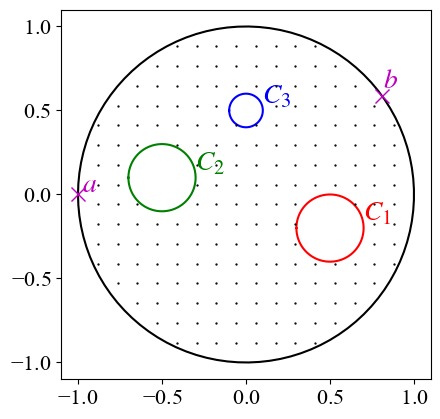

In [6]:
#a = -0.4j

[X, Y] = np.meshgrid(np.linspace(-1, 1, 18), np.linspace(-1, 1, 18))

plt.figure()
plt.plot(real(zp),imag(zp),'k-')
plt.plot(real(zp*qv[0]+dv[0]),imag(zp*qv[0]+dv[0]),'r-')
plt.plot(real(zp*qv[1]+dv[1]),imag(zp*qv[1]+dv[1]),'g-')
plt.plot(real(zp*qv[2]+dv[2]),imag(zp*qv[2]+dv[2]),'b-')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(xx,yy,'k.',markersize=1.3)
plt.xlim([-1.1,1.1]) 
plt.ylim([-1.1,1.1])  
plt.gca().set_aspect('equal', adjustable='box')
plt.plot(real(a),imag(a),"mx",markersize=10)
plt.plot(real(b),imag(b),"mx",markersize=10)
plt.text(real(dv[0]+qv[0])+0.01, imag(dv[0]+qv[0])+0.05, '$C_1$', color='r', fontsize=20, usetex=True)
plt.text(real(dv[1]+qv[1])+0.01, imag(dv[1]+qv[1])+0.05, '$C_2$', color='g', fontsize=20, usetex=True)
plt.text(real(dv[2]+qv[2])+0.01, imag(dv[2]+qv[2])+0.05, '$C_3$', color='b', fontsize=20, usetex=True)
plt.text(real(a)+0.03, imag(a)+0.02, r'$a$', color='m', fontsize=20, usetex=True)
plt.text(real(b)+0.01, imag(b)+0.05, r'$b$', color='m', fontsize=20, usetex=True)
#plt.savefig("map1.png")
#plt.savefig("output/figure2.pdf")
plt.show()





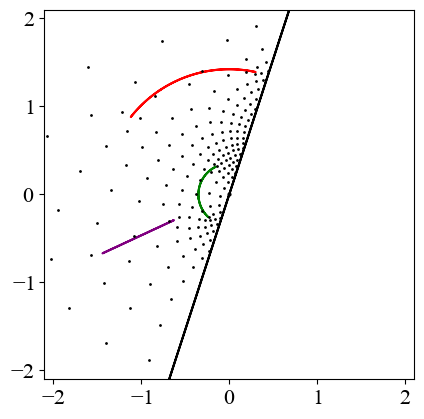

In [7]:
rc = 1
plt.figure()
plt.plot(real(map4(zp)),imag(map4(zp)),'k-')
plt.plot(real(map4(zp*qv[0]+dv[0])),imag(map4(zp*qv[0]+dv[0])),'r-')
plt.plot(real(map4(zp*qv[1]+dv[1])),imag(map4(zp*qv[1]+dv[1])),'g-')
plt.plot(real(map4(zp*qv[2]+dv[2])),imag(map4(zp*qv[2]+dv[2])),'-',color='purple')
plt.axis('equal')
for j in range(len(X)):
    for k in range(len(Y)):
        xx = X[j,k]
        yy = Y[j,k]
        if xx**2 + yy**2 < 1:
            if (xx - real(dv[0]))**2 + (yy - imag(dv[0]))**2 > qv[0]**2:
                if (xx - real(dv[1]))**2 + (yy - imag(dv[1]))**2 > qv[1]**2:
                    if (xx - real(dv[2]))**2 + (yy - imag(dv[2]))**2 > qv[2]**2:
                        plt.plot(real(map4(xx+1j*yy)),imag(map4(xx+1j*yy)),'k.',markersize=2)
                        #print("hoge")
plt.plot(0,0,"k.",markersize=4)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-2.1, 2.1)
plt.ylim(-2.1, 2.1)
#plt.savefig("output/map4.pdf")
plt.show()
